# Phân tích khám phá dữ liệu (EDA)
Dữ liệu bán hàng xe đạp Thống Nhất Bike — 2025-01 đến 2026-02

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

## Dữ liệu

In [2]:
df = pd.read_csv('../data/fact_sales.csv', low_memory=False)
df['order_date']   = pd.to_datetime(df['order_date'])
df['product_code'] = df['product_code'].astype(str).str.strip().str.zfill(15)
df['seg2_group']   = df['product_code'].str[6:9]
df['seg3_color']   = df['product_code'].str[9:12]
SEG2_MAP = {'002': 'Xe thường', '003': 'Địa hình', '004': 'Gấp', '005': 'Điện'}
df['group_name']  = df['seg2_group'].map(SEG2_MAP).fillna('Khác')
df['year_month']  = df['order_date'].dt.to_period('M')

# Bỏ 2026-03 (dữ liệu email, không phải đơn thực) và mã nhóm không hợp lệ
df = df[(df['year_month'].astype(str) != '2026-03') & (df['seg2_group'] != '00U')]

print(f'{len(df):,} dòng | {df["customer_code"].nunique()} đại lý | {df["product_code"].nunique()} SKU')
print(f'Khoảng thời gian: {df["year_month"].min()} → {df["year_month"].max()}')

34,062 dòng | 702 đại lý | 247 SKU
Khoảng thời gian: 2025-01 → 2026-02


## Thống kê cơ bản

In [3]:
print(f'  Số dòng   : {len(df):,}')
print(f'  Đại lý    : {df["customer_code"].nunique():,}')
print(f'  SKU       : {df["product_code"].nunique():,}')
print(f'  Vùng miền : {df["region"].nunique()}')
print()
print('Doanh thu từng dòng (VND):')
print(df['line_total'].describe().apply(lambda x: f'{x:,.0f}'))
print()
print('Giá trị thiếu:')
print(df[['customer_code','product_code','region','line_total','quantity']].isnull().sum())

  Số dòng   : 34,062
  Đại lý    : 702
  SKU       : 247
  Vùng miền : 3

Doanh thu từng dòng (VND):
count         34,062
mean       4,030,363
std        6,501,966
min          470,000
25%        1,561,389
50%        2,500,000
75%        4,400,000
max      202,222,222
Name: line_total, dtype: str

Giá trị thiếu:
customer_code      0
product_code       0
region           192
line_total         0
quantity           0
dtype: int64


## Doanh thu theo tháng

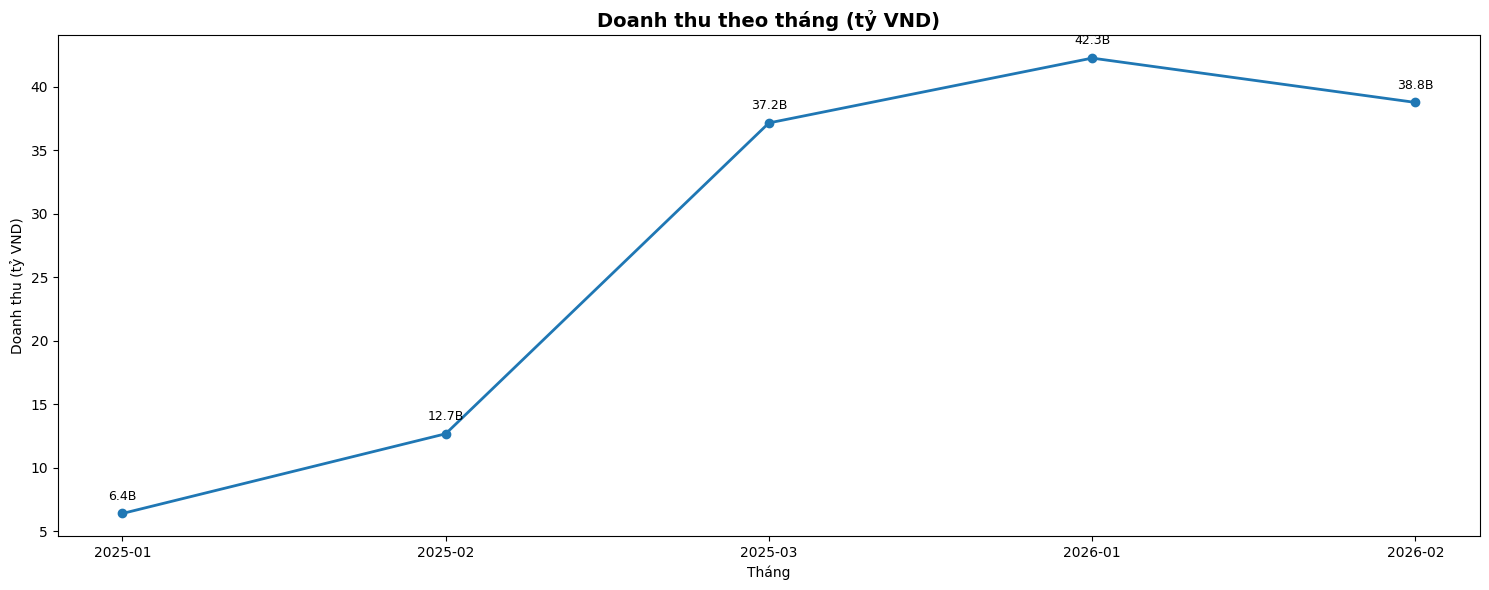

In [4]:
monthly = (df.groupby('year_month')['line_total']
             .sum()
             .reset_index())
monthly['period'] = monthly['year_month'].astype(str)
monthly['rev_b']  = monthly['line_total'] / 1e9

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(monthly['period'], monthly['rev_b'], marker='o', linewidth=2)
for _, row in monthly.iterrows():
    ax.annotate(f"{row['rev_b']:.1f}B", (row['period'], row['rev_b']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_title('Doanh thu theo tháng (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Doanh thu (tỷ VND)')
fig.tight_layout()
plt.show()

Doanh thu tăng mạnh từ ~6.4 tỷ (2025-01) lên đỉnh ~37.2 tỷ (2025-03), sau đó ổn định ~38–42 tỷ trong Q1/2026. Giai đoạn tăng tốc đầu 2025 phản ánh quá trình mở rộng kênh phân phối.

## Doanh thu theo nhóm sản phẩm

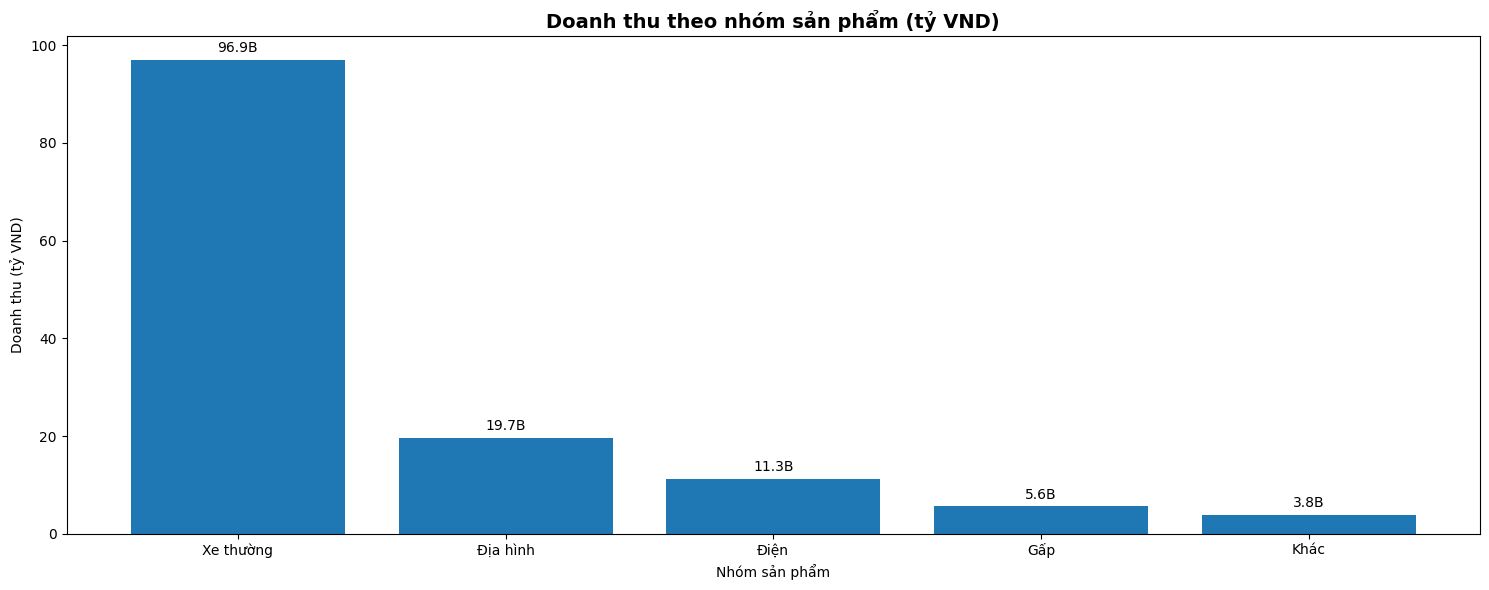

Tỷ lệ % theo nhóm:
group_name
Xe thường    70.6
Địa hình     14.3
Điện          8.2
Gấp           4.1
Khác          2.8


In [5]:
grp = (df.groupby('group_name')['line_total']
         .sum()
         .sort_values(ascending=False) / 1e9)

fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.bar(grp.index, grp.values)
for bar, val in zip(bars, grp.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + grp.values.max() * 0.01,
            f'{val:.1f}B', ha='center', va='bottom', fontsize=10)
ax.set_title('Doanh thu theo nhóm sản phẩm (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Nhóm sản phẩm')
ax.set_ylabel('Doanh thu (tỷ VND)')
fig.tight_layout()
plt.show()

print('Tỷ lệ % theo nhóm:')
print((grp / grp.sum() * 100).round(1).to_string())

Xe thường (002) chiếm >70% doanh thu. Xe gấp và xe điện còn nhỏ nhưng có tốc độ tăng trưởng đáng chú ý từ 2025-03.

## Top 10 đại lý theo doanh thu

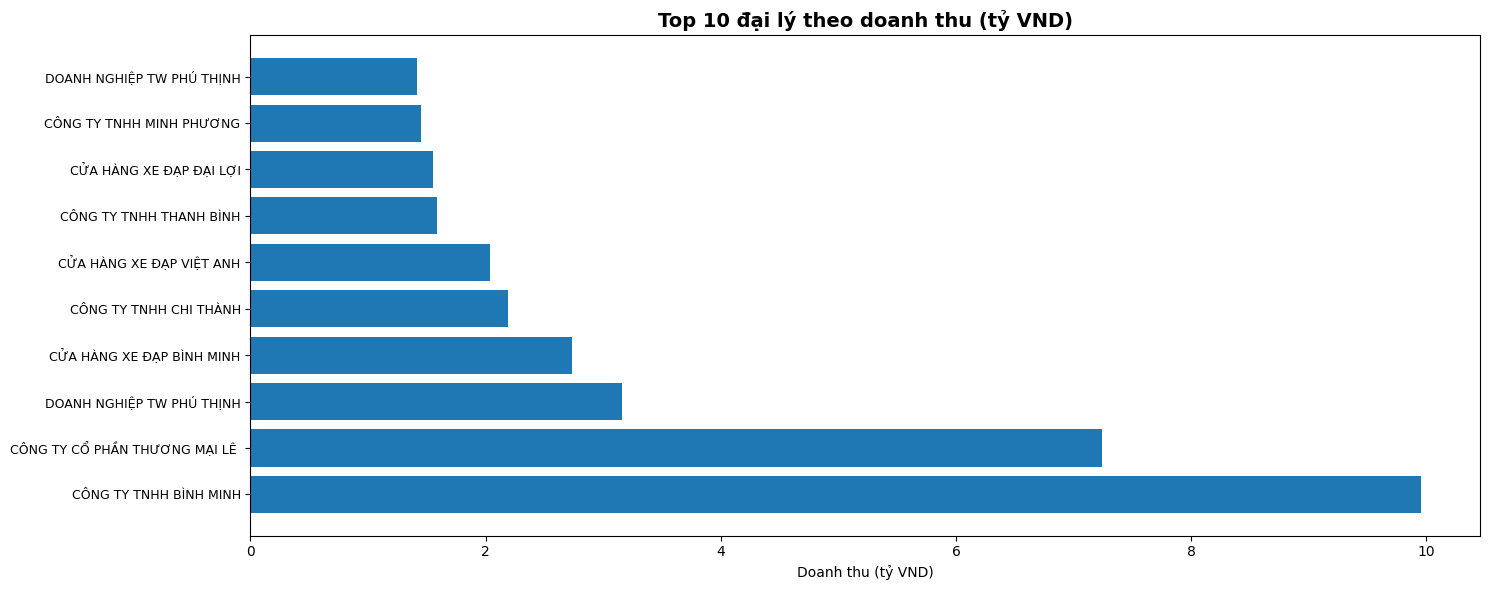

In [6]:
dealer_rev = (df.groupby(['customer_code','customer_name'])['line_total']
               .sum()
               .reset_index()
               .sort_values('line_total', ascending=False)
               .head(10))
dealer_rev['rev_b'] = dealer_rev['line_total'] / 1e9
labels = dealer_rev['customer_name'].str[:30].tolist()

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(range(len(dealer_rev)), dealer_rev['rev_b'].values)
ax.set_yticks(range(len(dealer_rev)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_title('Top 10 đại lý theo doanh thu (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Doanh thu (tỷ VND)')
fig.tight_layout()
plt.show()

Phân bố Pareto điển hình — 702 đại lý nhưng top 10 đóng góp phần lớn doanh số. Đây là nhóm cần ưu tiên chăm sóc và giữ chân.

## Phân phối màu sắc (top 15)

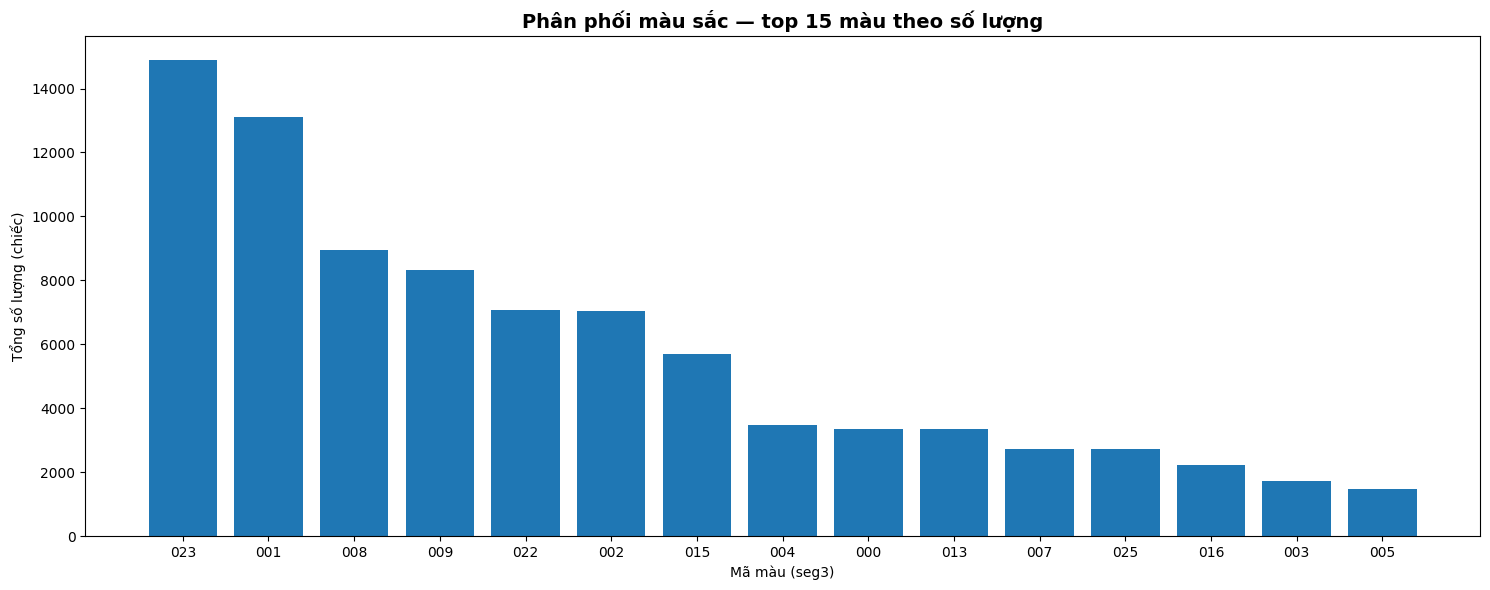

Top 5 màu:
seg3_color
023    14888.0
001    13100.0
008     8958.0
009     8314.0
022     7078.0


In [7]:
top15 = (df.groupby('seg3_color')['quantity']
           .sum()
           .sort_values(ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(top15.index, top15.values)
ax.set_title('Phân phối màu sắc — top 15 màu theo số lượng', fontsize=14, fontweight='bold')
ax.set_xlabel('Mã màu (seg3)')
ax.set_ylabel('Tổng số lượng (chiếc)')
fig.tight_layout()
plt.show()

print('Top 5 màu:')
print(top15.head().to_string())

Màu 023 và 001 dẫn đầu. Phân bố dài đuôi — top 5 màu chiếm phần lớn tổng số lượng.

## Heatmap doanh thu theo vùng × tháng

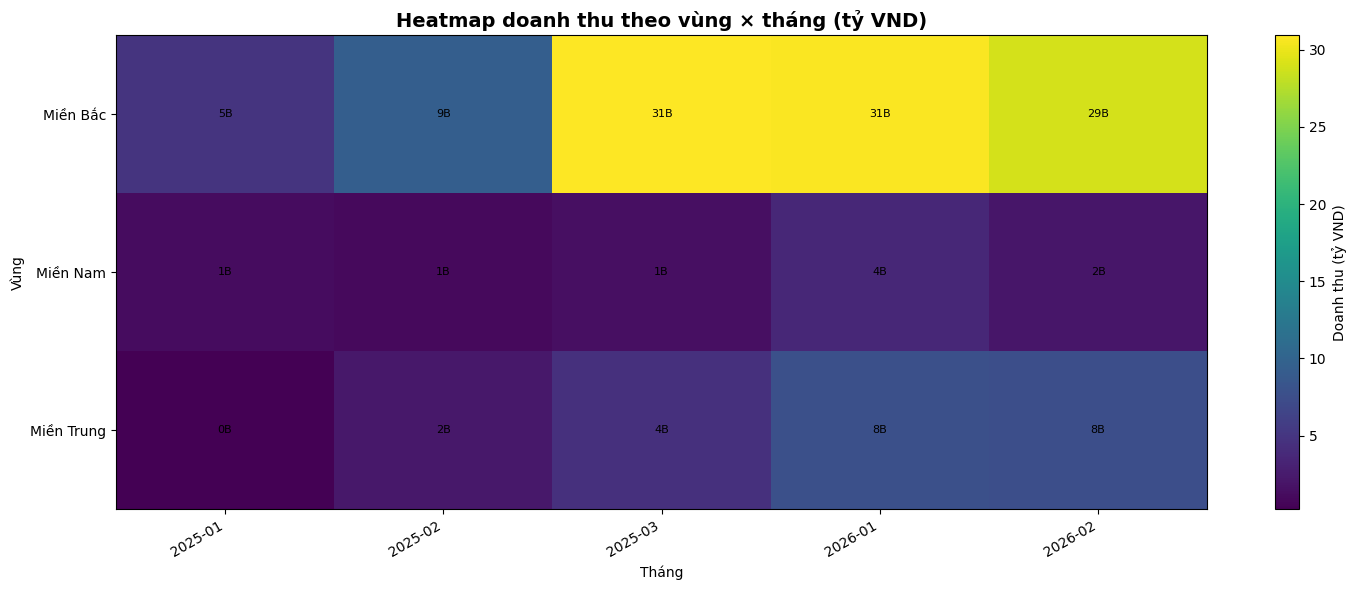

In [8]:
# Bỏ dòng thiếu tên vùng trước khi pivot
heat_df = df.dropna(subset=['region']).copy()
heat_df['period_str'] = heat_df['year_month'].astype(str)
pivot = (heat_df.groupby(['region','period_str'])['line_total']
                .sum()
                .unstack(fill_value=0)) / 1e9

fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(pivot.values, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i,j]:.0f}B', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Doanh thu (tỷ VND)')
ax.set_title('Heatmap doanh thu theo vùng × tháng (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Vùng')
fig.tight_layout()
plt.show()

Miền Nam dẫn đầu doanh thu hầu hết các tháng. 192 dòng thiếu thông tin vùng đã được loại trước khi vẽ.

## Phân tích thành phần chuỗi thời gian

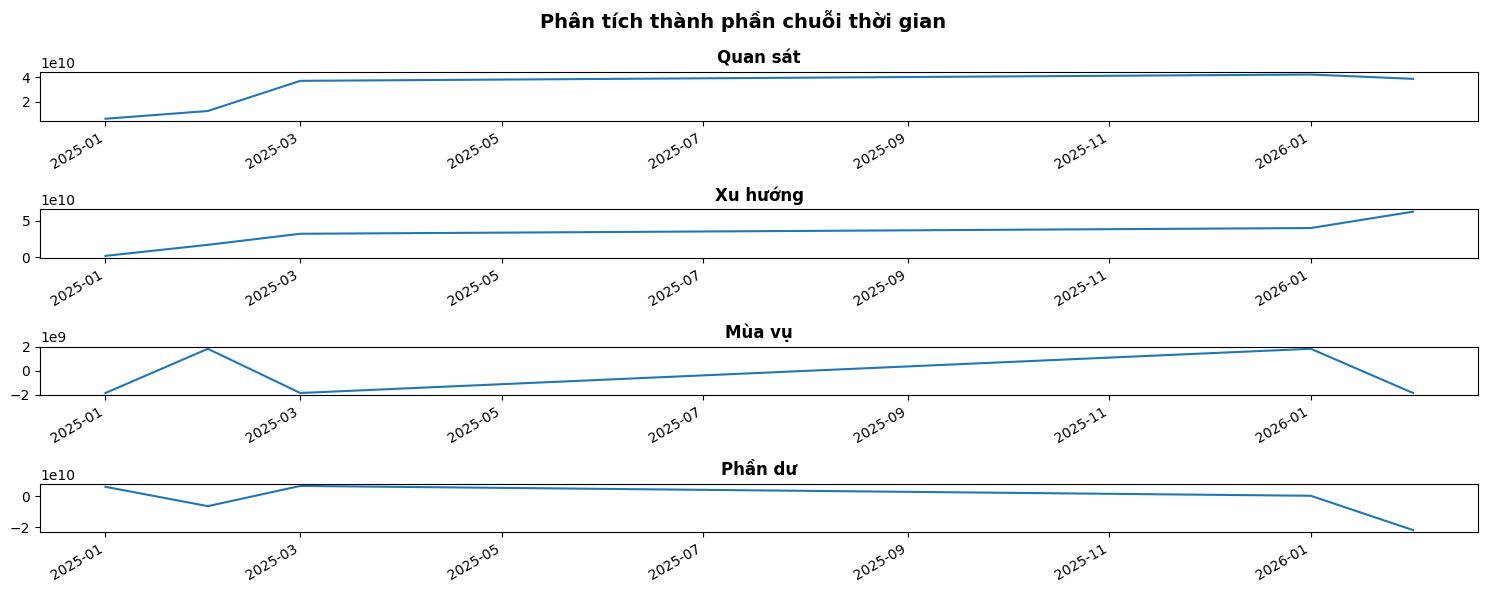

In [9]:
ts_monthly = df.groupby('year_month')['line_total'].sum()
ts_monthly.index = ts_monthly.index.to_timestamp()
ts_monthly = ts_monthly.sort_index()

# period=2 vì chỉ có 5 điểm; extrapolate_trend tránh NaN ở biên
result = seasonal_decompose(ts_monthly, model='additive',
                             period=2, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(15, 6))
parts = [
    (result.observed, 'Quan sát'),
    (result.trend,    'Xu hướng'),
    (result.seasonal, 'Mùa vụ'),
    (result.resid,    'Phần dư'),
]
for ax, (data, label) in zip(axes, parts):
    data.plot(ax=ax)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
fig.suptitle('Phân tích thành phần chuỗi thời gian', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

Xu hướng tăng mạnh 2025-01 → 2025-03 rồi phẳng lại. Với chỉ 5 điểm, kết quả mùa vụ mang tính tham khảo — cần thêm dữ liệu để kết luận chắc chắn.

## Tự tương quan (ACF / PACF)

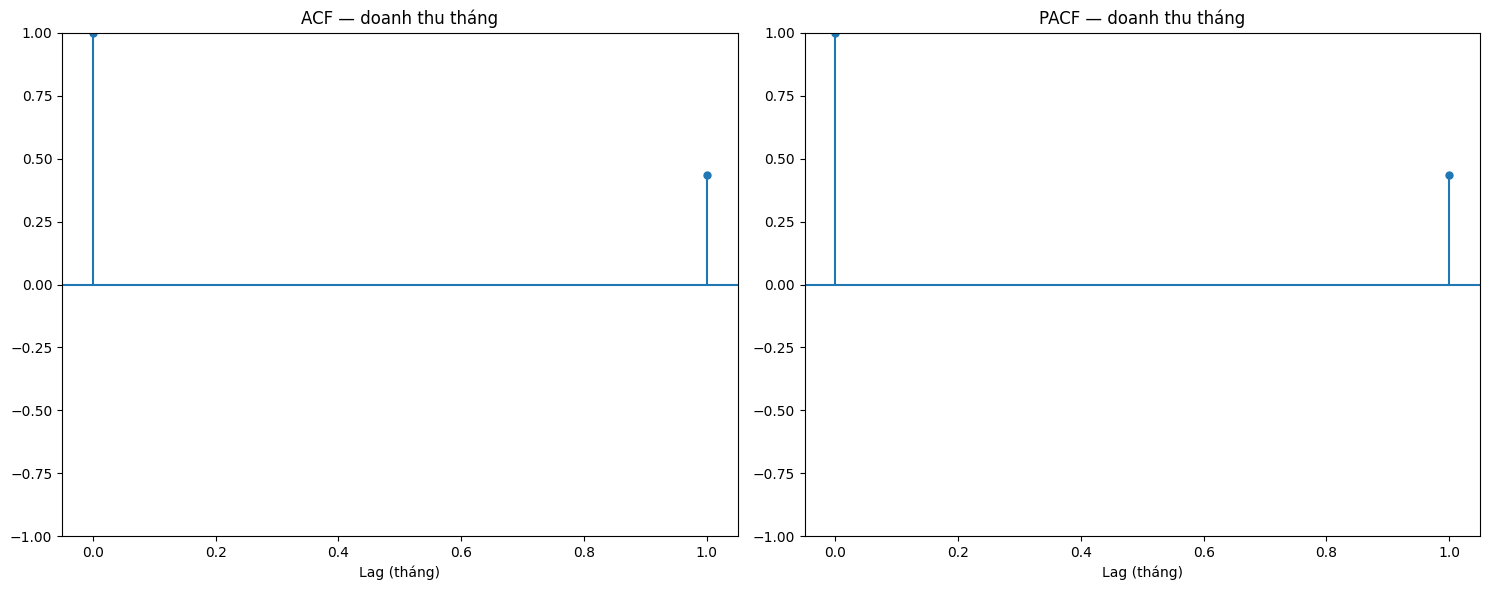

ACF lag-1 cao → tự tương quan mạnh, phù hợp mô hình AR hoặc LightGBM với lag features.


In [10]:
# PACF yêu cầu số lag < n/2 — với 5 điểm, tối đa 1 lag
safe_lags = max(1, len(ts_monthly) // 2 - 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(ts_monthly,  lags=safe_lags, ax=ax1, title='ACF — doanh thu tháng')
plot_pacf(ts_monthly, lags=safe_lags, ax=ax2, title='PACF — doanh thu tháng')
ax1.set_xlabel('Lag (tháng)')
ax2.set_xlabel('Lag (tháng)')
fig.tight_layout()
plt.show()

print('ACF lag-1 cao → tự tương quan mạnh, phù hợp mô hình AR hoặc LightGBM với lag features.')

Khoảng tin cậy rộng do ít điểm. Lag-1 có tự tương quan dương → doanh thu tháng trước là tín hiệu dự báo tháng sau.

## Số lượng xe bán và cơ cấu nhóm theo tháng

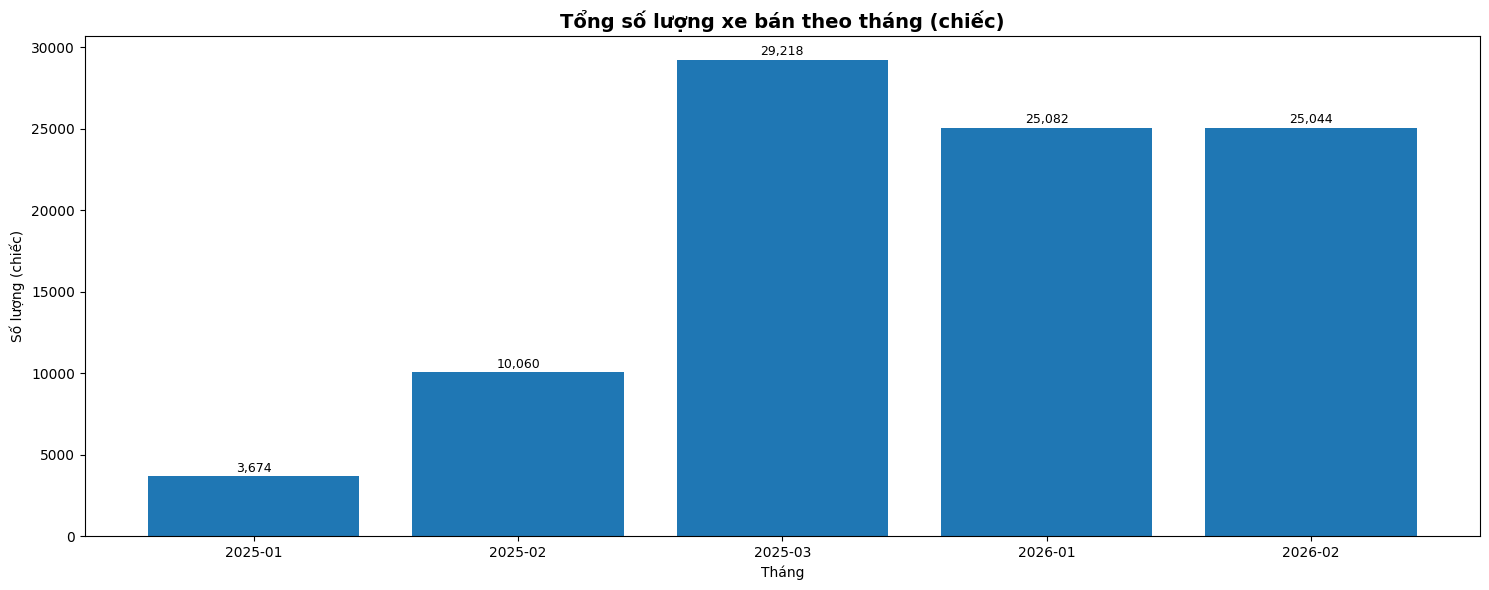

In [11]:
qty_monthly = (df.assign(period=df['order_date'].dt.to_period('M').astype(str))
                 .groupby('period')['quantity']
                 .sum()
                 .reset_index())

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(qty_monthly['period'], qty_monthly['quantity'])
for _, row in qty_monthly.iterrows():
    ax.text(row['period'], row['quantity'] + qty_monthly['quantity'].max() * 0.01,
            f"{row['quantity']:,.0f}", ha='center', fontsize=9)
ax.set_title('Tổng số lượng xe bán theo tháng (chiếc)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Số lượng (chiếc)')
fig.tight_layout()
plt.show()

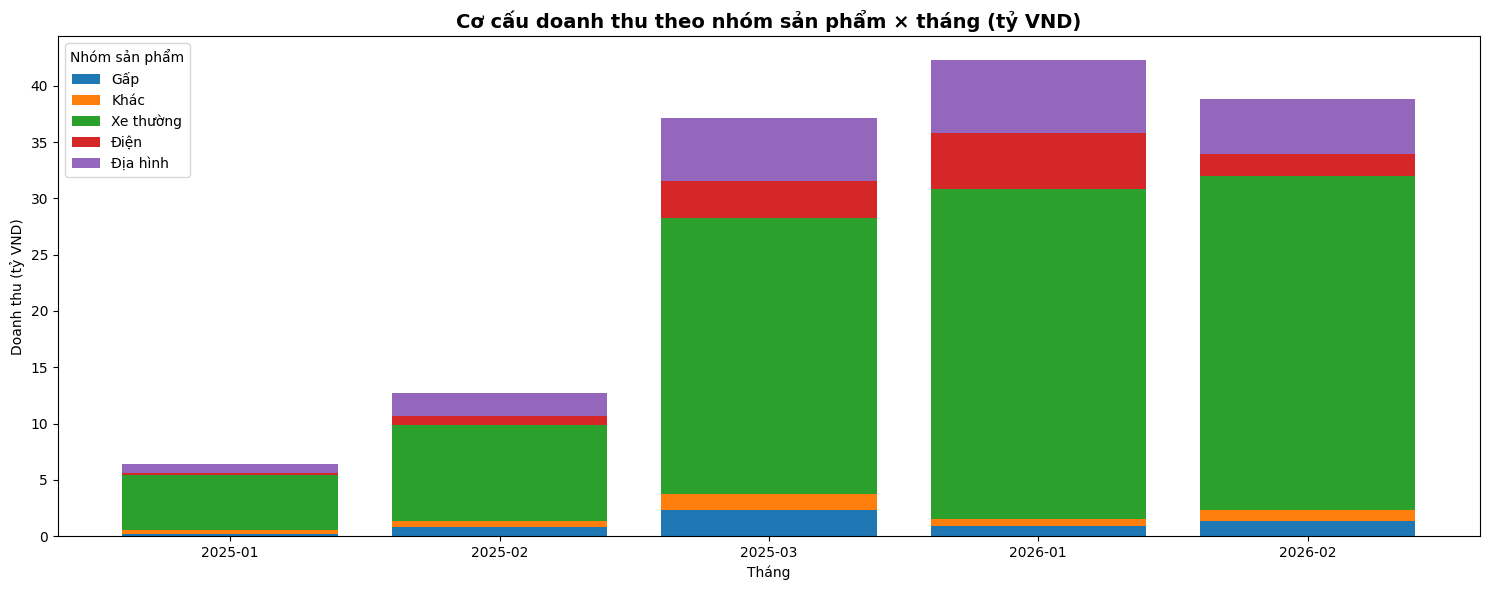

In [12]:
pivot_grp = (df.assign(period=df['year_month'].astype(str))
               .groupby(['period','group_name'])['line_total']
               .sum()
               .unstack(fill_value=0) / 1e9)

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(pivot_grp))
for col in pivot_grp.columns:
    ax.bar(pivot_grp.index, pivot_grp[col], bottom=bottom, label=col)
    bottom += pivot_grp[col].values
ax.set_title('Cơ cấu doanh thu theo nhóm sản phẩm × tháng (tỷ VND)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Doanh thu (tỷ VND)')
ax.legend(title='Nhóm sản phẩm')
fig.tight_layout()
plt.show()

Xe thường chiếm áp đảo toàn bộ giai đoạn. Xe điện bắt đầu xuất hiện từ 2025-03 — tín hiệu danh mục mới cần theo dõi.

## Tổng kết

Doanh thu tăng mạnh từ 6.4 tỷ lên 42 tỷ VND/tháng trong 5 tháng quan sát. Xe thường chiếm >70% tổng doanh thu. Top 10 đại lý đóng góp phần lớn doanh số theo phân bố Pareto. Màu 023 và 001 dẫn đầu về số lượng. ACF lag-1 dương xác nhận chuỗi thời gian có tính trễ — phù hợp với các mô hình được dùng ở notebook 01.

Lưu ý: 2026-03 và mã seg2='00U' đã được loại khỏi toàn bộ phân tích.